#Reconstrucción de Rompecabezas y Clasificación de Objetos



In [ ]:
#librerias
import cv2, numpy as np, glob, os, matplotlib.pyplot as plt
print("OpenCV:", cv2.__version__)

def mostrar(img_bgr, title=""):
    plt.figure(figsize=(7,7))
    plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    plt.title(title); plt.axis("off"); plt.show()

OpenCV: 4.13.0


##Cargamos las imágenes

Se sube el archivo **`imagen1.zip`** o desde la computadora.
El zip debe contener:
- una imagen cuyo nombre incluya **`referencia`**
- las piezas cuyos nombres incluyan **`pieza`**


In [ ]:
#subimos el zip
try:
    from google.colab import files
    up = files.upload()
    ZIP = list(up.keys())[0]
except Exception as e:
    ZIP = "imagen1.zip"  #ya cargado

!unzip -o "$ZIP" -d /content/data > /dev/null 2>&1
!find /content/data -type f | sort

Saving imagen1.zip to imagen1.zip
/content/data/imagen1/imagen_referencia_512.png
/content/data/imagen1/pieza_01.png
/content/data/imagen1/pieza_02.png
/content/data/imagen1/pieza_03.png
/content/data/imagen1/pieza_04.png
/content/data/imagen1/pieza_05.png
/content/data/imagen1/pieza_06.png
/content/data/imagen1/pieza_07.png
/content/data/imagen1/pieza_08.png
/content/data/imagen1/pieza_09.png
/content/data/imagen1/pieza_10.png
/content/data/imagen1/pieza_11.png
/content/data/imagen1/pieza_12.png
/content/data/imagen1/pieza_13.png
/content/data/imagen1/pieza_14.png
/content/data/imagen1/pieza_15.png


### Detección automática de la referencia y las piezas

In [ ]:
#busca archivos
archivos = glob.glob("/content/data/**/*.png", recursive=True) + \
           glob.glob("/content/data/**/*.jpg", recursive=True)

REF = None #imagen de referencia
piezas = [] #piezas

for f in archivos:
    archivo_min = f.lower()  #ruta a minusculas

    if "referencia" in archivo_min:
        REF = f
    elif "pieza" in archivo_min:
        piezas.append(f)

piezas.sort()
print("Referencia:", REF)
print("Número de piezas:", len(piezas))

Referencia: /content/data/imagen1/imagen_referencia_512.png
Número de piezas: 15


##Reconstrucción POR BORDES

Arma el rompecabezas comparando solo los **bordes** de las piezas entre usando tres tecnicas:

- **Color en los bordes:** se comparan las columnas/filas de píxeles del borde (en espacio **LAB**) con una pequeña búsqueda de desfase vertical/horizontal (SSD de color).
- **Sobel (gradientes):** métrica **MGC** (*Mahalanobis Gradient Compatibility*), que usa el **gradiente saliente** del borde (equivalente a Sobel) para *predecir* el píxel del vecino y penalizar discontinuidades.
- **Canny:** mapa de bordes para (1) **enderezar** cada pieza (deskew, por si vienen rotadas) y (2) penalizar cuando los bordes detectados **no tienen continuidad** entre dos piezas contiguas.

In [ ]:
#detectamos los bordes para cada pieza del rompecabezas
def filtro_sobel(img):
  alto, ancho = img.shape
  salida = np.zeros((alto, ancho), dtype=np.float32)

  mascara_x = [[-1, 0, 1],
               [-2, 0, 2],
               [-1, 0, 1]]

  mascara_y = [[-1, -2, -1],
               [ 0,  0,  0],
               [ 1,  2,  1]]

  #para cada pixel calcula el gradiente horizontal y vertical
  for fila in range(1, alto - 1):
    for columna in range(1, ancho - 1):
      gx = 0
      gy = 0
      for i in range(3):
        for j in range(3):
          pixel = float(img[fila-1+i][columna-1+j])

          gx += pixel*mascara_x[i][j]
          gy += pixel*mascara_y[i][j]

      #obtenemos la intensidad del borde
      magnitud = (gx**2 + gy**2)**0.5

      if magnitud > 255:
        magnitud = 255

      salida[fila][columna] = magnitud

  return salida.astype(np.uint8)

In [ ]:
#preparamos la☼ piezas
def preparar_pieza(ruta):
    #leemos iamgen(rgb) + canal alfa (transparencia)
    imagen = cv2.imread(ruta, cv2.IMREAD_UNCHANGED)
    #separamos
    color = imagen[:, :, :3]
    alfa = imagen[:, :, 3]

    #creamos una mascara para identificar la parte donde existe la pieza
    mascara = (alfa > 10).astype(np.uint8)
    #contorno de la pieza
    contornos, _ = cv2.findContours(mascara,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
    contorno = max(contornos, key=cv2.contourArea) #contorno

    #calculamos la posicion y orientacion
    (cx, cy), (ancho, alto), angulo = cv2.minAreaRect(contorno) #rectangulo que lo contiene
    if angulo < -45:
        angulo = angulo + 90

    #creamos la matriz de rotacion y giramos la pieza
    matriz = cv2.getRotationMatrix2D((cx, cy), angulo, 1.0)
    imagen_rotada = cv2.warpAffine(color,matriz,(color.shape[1], color.shape[0]))
    #rotamos la mascara para poder recortar
    alfa_rotado = cv2.warpAffine(alfa,matriz,(alfa.shape[1], alfa.shape[0]))
    #buscamos los pixeles donde existe la pieza
    filas, columnas = np.where(alfa_rotado > 10)

    #eecortamos solamente la zona ocupada por la pieza
    pieza = imagen_rotada[
        filas.min():filas.max()+1,
        columnas.min():columnas.max()+1]

    return pieza

#guardamos las pieza☼ ya corregidas
piezas_n = []
for archivo in piezas:
    pieza = preparar_pieza(archivo)
    piezas_n.append(pieza)

#calculamos el tamaño promedio de las piezas
anchos = []
altos = []
for pieza in piezas_n:
    altos.append(pieza.shape[0])
    anchos.append(pieza.shape[1])
ancho_promedio = int(np.median(anchos))
alto_promedio = int(np.median(altos))

#todas las piezas tendran el mismo tamaño
for i in range(len(piezas_n)):
    piezas_n[i] = cv2.resize(piezas_n[i], (ancho_promedio, alto_promedio))

N = len(piezas_n)

#convertimos las piezas RGB al espacio de color LAB
#para comparar mejor las diferencias de color
lab = []
for pieza in piezas_n:
    imagen_lab = cv2.cvtColor(pieza, cv2.COLOR_BGR2LAB)
    lab.append(imagen_lab.astype(np.float64))

#aplicamos filtro Sobel para obtener informacion de los bordes
grads = []
for pieza in piezas_n:
    gris = cv2.cvtColor(pieza, cv2.COLOR_BGR2GRAY)
    sobel = filtro_sobel(gris)
    grads.append(sobel)

#aplicamos Canny para detectar los contornos de cada pieza
edges = []
for pieza in piezas_n:
    borde = cv2.Canny(pieza, 50, 150)
    edges.append(borde)

print("Piezas:", N)
print("Tamaño normalizado:", (ancho_promedio, alto_promedio))

Piezas: 15
Tamaño normalizado: (107, 184)


In [ ]:
#comparamos los gradientes Sobel entre dos piezas
def comparar_sobel(i, j, lado):
  if lado == "costo_derecha":
    borde1 = grads[i][:, -1]
    borde2 = grads[j][:, 0]
  else:
    borde1 = grads[i][-1, :]
    borde2 = grads[j][0, :]

  borde1 = borde1.astype(np.float32)
  borde2 = borde2.astype(np.float32)

  #diferencia promedio
  diferencia = np.abs(borde1 - borde2)
  promedio = np.mean(diferencia)

  return promedio

#comparamos el color de los bordes
def color_ssd(pieza1, pieza2, lado, desplazamiento=0):
  if lado == "costo_derecha":
    borde1 = pieza1[:, -1, :]
    borde2 = pieza2[:, 0, :]
  else:
    borde1 = pieza1[-1, :, :]
    borde2 = pieza2[0, :, :]

  if desplazamiento > 0:
    borde1 = borde1[desplazamiento:]
    borde2 = borde2[:len(borde1)]
  elif desplazamiento < 0:
    borde2 = borde2[-desplazamiento:]
    borde1 = borde1[:len(borde2)]

  cantidad = min(len(borde1), len(borde2))
  diferencia = borde1[:cantidad] - borde2[:cantidad]
  error = np.mean(diferencia ** 2)

  return float(error)


#comparamos continuidad usando Canny
def canny_mismatch(i, j, lado):
  if lado == "costo_derecha":
    borde1 = edges[i][:, -1] > 0
    borde2 = edges[j][:, 0] > 0
  else:
    borde1 = edges[i][-1, :] > 0
    borde2 = edges[j][0, :] > 0

  diferencia = np.mean(borde1 != borde2)

  return float(diferencia)


#comparamos el costo entre dos piezas
def calcular_costo(i, j, lado):
  pieza1 = lab[i]
  pieza2 = lab[j]

  mejor_color = float("inf")

  for desplazamiento in range(-3, 4):
    valor = color_ssd(pieza1, pieza2, lado, desplazamiento)
    if valor < mejor_color:
      mejor_color = valor

  valor_sobel = comparar_sobel(i, j, lado)
  valor_canny = canny_mismatch(i, j, lado)
  costo_total = mejor_color + 2*valor_sobel + 100*valor_canny

  return costo_total


#matrices de compatibilidad
costo_derecha = np.full((N, N), 1e18)
costo_abajo = np.full((N, N), 1e18)

for i in range(N):
  for j in range(N):
    if i == j:
      continue

    costo_derecha[i, j] = calcular_costo(i, j, "costo_derecha")
    costo_abajo[i, j] = calcular_costo(i, j, "costo_abajo")

print("Matrices de compatibilidad de bordes calculadas.")

Matrices de compatibilidad de bordes calculadas.


In [ ]:
#calculamos el tamaño del tablero
aspecto = alto_promedio / ancho_promedio
divisiones = []

for filas in range(1, N + 1):
    if N % filas == 0:
        columnas = N // filas
        divisiones.append((filas, columnas))

mejor_diferencia = float("inf")

#buscamos todas las combinaciones de filas y columnas
#cuyo prodcucto sea igual al numero total de piezas
for filas, columnas in divisiones:
    diferencia = abs((columnas / filas) - aspecto)
    if diferencia < mejor_diferencia:
        mejor_diferencia = diferencia

        ROWS = filas
        COLS = columnas
print("Posible tamaño del tablero:", ROWS, "x", COLS)

#construimos el rompecabezas agregando las piezas una por una
def armar_rompecabezas(semilla):
  posiciones = {} #guarda la posicion de las piezas colocadas
  posiciones[(0, 0)] = semilla

  usadas = set()
  usadas.add(semilla) #piezas que ya fueron utilizadas

  fila_min = 0
  fila_max = 0
  columna_min = 0
  columna_max = 0

  while len(usadas) < N:
    mejor_costo = None
    mejor_posicion = None
    mejor_pieza = None

    candidatos = {} #posiciones disponibles alrededor de las piezas colocadas

    for fila, columna in posiciones:
      vecinos = [
                (0, 1),
                (0, -1),
                (1, 0),
                (-1, 0)]

      for df, dc in vecinos:
        nueva = (fila + df, columna + dc)

        if nueva in posiciones:
          continue

        alto = max(fila_max, nueva[0]) - min(fila_min, nueva[0]) + 1
        ancho = max(columna_max, nueva[1]) - min(columna_min, nueva[1]) + 1

        if alto > ROWS:
          continue

        if ancho > COLS:
          continue

        #evitamos colocar dos piezas en el mismo lugar
        if nueva not in candidatos:
          candidatos[nueva] = []

        candidatos[nueva].append((fila, columna))

    #probamos que pieza encaja mejor en cada posicion disponible
    for posicion in candidatos:
      vecinos = candidatos[posicion]

      for pieza in range(N):
        if pieza in usadas:
          continue

        costo = 0

        #calculamos el costo con las piezas vecinas
        for fila, columna in vecinos:
          pieza_vecina = posiciones[(fila, columna)]

          if posicion[1] == columna + 1:
            costo += costo_derecha[pieza_vecina, pieza]

          elif posicion[1] == columna - 1:
            costo += costo_derecha[pieza, pieza_vecina]

          elif posicion[0] == fila + 1:
            costo += costo_abajo[pieza_vecina, pieza]

          else:
            costo += costo_abajo[pieza, pieza_vecina]

        costo = costo / len(vecinos)

        if mejor_costo is None or costo < mejor_costo:
          mejor_costo = costo
          mejor_posicion = posicion
          mejor_pieza = pieza

    #guardamos la pieza con menor costo encontrado
    posiciones[mejor_posicion] = mejor_pieza
    usadas.add(mejor_pieza)

    #actualizamos los limites del tablero
    fila_min = min(fila_min, mejor_posicion[0])
    fila_max = max(fila_max, mejor_posicion[0])
    columna_min = min(columna_min, mejor_posicion[1])
    columna_max = max(columna_max, mejor_posicion[1])

  fila_inicial = min(pos[0] for pos in posiciones)
  columna_inicial = min(pos[1] for pos in posiciones)

  #guardaremos las piezas en el tblero
  tablero = []

  for i in range(ROWS):
    fila = []
    for j in range(COLS):
      fila.append(None)

    tablero.append(fila)

  #pasamos las piezas al tablero
  for posicion in posiciones:
    fila = posicion[0] - fila_inicial
    columna = posicion[1] - columna_inicial

    tablero[fila][columna] = posiciones[posicion]

  #calculamos el costo total de la reconstruccion
  costo_total = 0

  for fila in range(ROWS):
    for columna in range(COLS):
      if columna + 1 < COLS:
        izquierda = tablero[fila][columna]
        derecha = tablero[fila][columna + 1]

        costo_total += costo_derecha[izquierda, derecha]

      if fila + 1 < ROWS:
        arriba = tablero[fila][columna]
        abajo = tablero[fila + 1][columna]

        costo_total += costo_abajo[arriba, abajo]

  return tablero, costo_total

Posible tamaño del tablero: 3 x 5


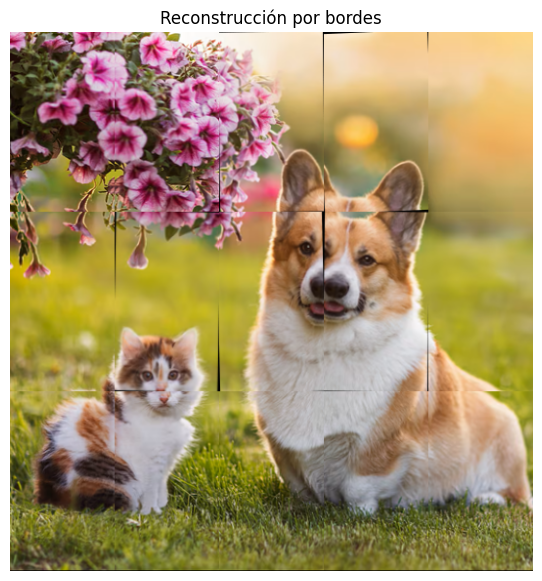

Orden de piezas:
[1, 2, 3, 4, 5]
[6, 7, 8, 9, 10]
[11, 12, 13, 14, 15]


In [ ]:
#buscamos el mejor armado de tablero
mejor_tablero = None
mejor_costo = None

for semilla in range(N):
    tablero, costo = armar_rompecabezas(semilla)

    if mejor_costo is None or costo < mejor_costo:
        mejor_costo = costo
        mejor_tablero = tablero

grid = mejor_tablero

#construimos la iamen final
canvas_b = np.zeros((alto_promedio*ROWS, ancho_promedio*COLS, 3), np.uint8)

for fila in range(ROWS):
    for columna in range(COLS):
        pieza = grid[fila][columna]
        canvas_b[
            fila * alto_promedio:(fila + 1) * alto_promedio,
            columna * ancho_promedio:(columna + 1) * ancho_promedio
        ] = piezas_n[pieza]

cv2.imwrite("/content/reconstruida_bordes.png", canvas_b)
mostrar(canvas_b, "Reconstrucción por bordes")
print("Orden de piezas:")

for fila in grid:
    resultado = []
    for pieza in fila:
        resultado.append(pieza + 1)
    print(resultado)

## Detección y clasificación de objetos

**YOLOv8n** pre-entrenado en el dataset **COCO** (80 clases) y mapeamos cada clase detectada a una de las **4 categorías**:

| Categoría | Clases COCO incluidas |
|---|---|
| **Frutas** | banana, apple, orange, y otras frutas/comida |
| **Animales** | bird, cat, dog, horse, sheep, cow, elephant, bear, zebra, giraffe |
| **Personas** | person |
| **Objetos** | el resto de clases |


In [ ]:
!pip install ultralytics fiftyone scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 3.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.5/19.5 MB 81.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.9/112.9 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.5/112.5 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.8/74.8 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 14.6 MB/s eta 0:0

In [ ]:
import ultralytics
print(ultralytics.__version__)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
8.4.104


In [ ]:
from ultralytics import YOLO
modelo = YOLO("yolov8n.pt")

modelo.info()

YOLOv8n summary: 129 layers, 3,157,200 parameters, 0 gradients, 8.9 GFLOPs


(129, 3157200, 0, 8.8575488)

In [ ]:
clases_coco = modelo.names
print("Número de clases COCO:", len(clases_coco))

for id, nombre in clases_coco.items():
    print(id, ":", nombre)

Número de clases COCO: 80
0 : person
1 : bicycle
2 : car
3 : motorcycle
4 : airplane
5 : bus
6 : train
7 : truck
8 : boat
9 : traffic light
10 : fire hydrant
11 : stop sign
12 : parking meter
13 : bench
14 : bird
15 : cat
16 : dog
17 : horse
18 : sheep
19 : cow
20 : elephant
21 : bear
22 : zebra
23 : giraffe
24 : backpack
25 : umbrella
26 : handbag
27 : tie
28 : suitcase
29 : frisbee
30 : skis
31 : snowboard
32 : sports ball
33 : kite
34 : baseball bat
35 : baseball glove
36 : skateboard
37 : surfboard
38 : tennis racket
39 : bottle
40 : wine glass
41 : cup
42 : fork
43 : knife
44 : spoon
45 : bowl
46 : banana
47 : apple
48 : sandwich
49 : orange
50 : broccoli
51 : carrot
52 : hot dog
53 : pizza
54 : donut
55 : cake
56 : chair
57 : couch
58 : potted plant
59 : bed
60 : dining table
61 : toilet
62 : tv
63 : laptop
64 : mouse
65 : remote
66 : keyboard
67 : cell phone
68 : microwave
69 : oven
70 : toaster
71 : sink
72 : refrigerator
73 : book
74 : clock
75 : vase
76 : scissors
77 : teddy 

#Descarga del dataset COCO

In [ ]:
import fiftyone as fo
import fiftyone.zoo as foz
import random
import shutil

#elimina datasets antiguos de FiftyOne
#fo.delete_datasets("*")

#clases de COCO para las 4 categorias
clases_personas = ["person"]

clases_animales = [
    "bird", "cat", "dog", "horse", "sheep",
    "cow", "elephant", "bear", "zebra", "giraffe"
]

clases_frutas = ["apple", "banana", "orange", "broccoli", "carrot"]

clases_objetos = [
    "backpack", "umbrella", "handbag", "tie",
    "suitcase", "chair", "couch", "bed",
    "dining table", "tv", "laptop",
    "cell phone", "book", "clock"
]

#unimos todas las clases que seran descargadas desde COCO
todas_las_clases = (
    clases_personas +
    clases_animales +
    clases_frutas +
    clases_objetos
)

#generamos un identificador aleatorio
token = random.randint(1000,9999)

#eliminamos una posible descarga anterior del dataset
import shutil
shutil.rmtree("/root/fiftyone/coco-2017",ignore_errors=True)

#descargamos imágenes del dataset COCO que contengan las clases seleccionadas
print("Descargando COCO...")

dataset = foz.load_zoo_dataset(
    "coco-2017",
    split="train",
    label_types=["detections"],
    classes=todas_las_clases,
    max_samples=6000,
    dataset_name=f"coco_{token}"
)

print("Imágenes descargadas:", len(dataset))

/usr/local/lib/python3.12/dist-packages/glob2/fnmatch.py:141: SyntaxWarning: invalid escape sequence '\Z'
  return '(?ms)' + res + '\Z'


Descargando COCO...


INFO:fiftyone.zoo.datasets:Downloading split 'train' to '/root/fiftyone/coco-2017/train' if necessary


INFO:fiftyone.utils.coco:Downloading annotations to '/root/fiftyone/coco-2017/tmp-download/annotations_trainval2017.zip'


 100% |██████|    1.9Gb/1.9Gb [4.7s elapsed, 0s remaining, 464.3Mb/s]       


...

 100% |███████████████| 6000/6000 [43.9s elapsed, 0s remaining, 173.8 samples/s]      


INFO:eta.core.utils: 100% |███████████████| 6000/6000 [43.9s elapsed, 0s remaining, 173.8 samples/s]      


Dataset 'coco_6137' created


INFO:fiftyone.zoo.datasets:Dataset 'coco_6137' created


Imágenes descargadas: 6000


#Contamos imágenes por macroclase

In [ ]:
from collections import Counter

#diccionario para convertir las clases originales de COCO
#en las cuatro categorías principales del proyecto
macroclases = {}

for clase in clases_personas:
    macroclases[clase] = "personas"

for clase in clases_animales:
    macroclases[clase] = "animales"

for clase in clases_frutas:
    macroclases[clase] = "frutas"

for clase in clases_objetos:
    macroclases[clase] = "objetos"

contador = Counter() #cantidad de imagenes q contiene cada categoría

for muestra in dataset:
    clases_imagen = set() #no contamos 2 veces la misma categoría dentro de una imagen
    #revisamos todas las detecciones presentes en la imagen
    for d in muestra.ground_truth.detections:
        if d.label in macroclases:
            clases_imagen.add(macroclases[d.label])
    #incrementamos el contador por cada categoría encontrada
    for clase in clases_imagen:
        contador[clase] += 1
print(contador)

Counter({'personas': 3942, 'objetos': 2777, 'animales': 1506, 'frutas': 412})


#Exportamos el dataset al formato YOLO

In [ ]:
import shutil

#eliminamos una exportación anterior si existe
shutil.rmtree("/content/dataset_temporal", ignore_errors=True)

#formato YOLO(imagenes + etiquetas .txt)
dataset.export(
    export_dir="/content/dataset_temporal",
    dataset_type=fo.types.YOLOv5Dataset,
    classes=todas_las_clases
)

print("Exportación completada")

   0% |/--------------|   30/6000 [122.1ms elapsed, 24.3s remaining, 245.7 samples/s] 

/usr/local/lib/python3.12/dist-packages/fiftyone/utils/yolo.py:1154: UserWarning: Ignoring object with label 'bowl' not in provided classes
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/fiftyone/utils/yolo.py:1154: UserWarning: Ignoring object with label 'potted plant' not in provided classes
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/fiftyone/utils/yolo.py:1154: UserWarning: Ignoring object with label 'car' not in provided classes
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/fiftyone/utils/yolo.py:1154: UserWarning: Ignoring object with label 'truck' not in provided classes
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/fiftyone/utils/yolo.py:1154: UserWarning: Ignoring object with label 'stop sign' not in provided classes
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/fiftyone/utils/yolo.py:1154: UserWarning: Ignoring object with label 'bicycle' not in provided classes
  warnings.warn(msg)
/usr/local/lib/pyt

   2% |\--------------|   97/6000 [327.3ms elapsed, 19.9s remaining, 296.4 samples/s] 

/usr/local/lib/python3.12/dist-packages/fiftyone/utils/yolo.py:1154: UserWarning: Ignoring object with label 'boat' not in provided classes
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/fiftyone/utils/yolo.py:1154: UserWarning: Ignoring object with label 'tennis racket' not in provided classes
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/fiftyone/utils/yolo.py:1154: UserWarning: Ignoring object with label 'donut' not in provided classes
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/fiftyone/utils/yolo.py:1154: UserWarning: Ignoring object with label 'airplane' not in provided classes
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/fiftyone/utils/yolo.py:1154: UserWarning: Ignoring object with label 'toilet' not in provided classes
  warnings.warn(msg)


   3% |---------------|  159/6000 [986.8ms elapsed, 36.2s remaining, 161.1 samples/s] 

...

  32% |████\----------| 1895/6000 [7.3s elapsed, 15.3s remaining, 286.1 samples/s]    

/usr/local/lib/python3.12/dist-packages/fiftyone/utils/yolo.py:1154: UserWarning: Ignoring object with label 'toaster' not in provided classes
  warnings.warn(msg)


 100% |███████████████| 6000/6000 [23.0s elapsed, 0s remaining, 283.5 samples/s]      


INFO:eta.core.utils: 100% |███████████████| 6000/6000 [23.0s elapsed, 0s remaining, 283.5 samples/s]      


Exportación completada


#Contamos las etiquetas exportadas

In [ ]:
from collections import Counter
import glob

contador = Counter() #contar cuantos objetos existen por clase

for archivo in glob.glob(
    "/content/dataset_temporal/labels/**/*.txt",
    recursive=True
):
    with open(archivo) as f:
        for linea in f:
            #el primer numero de cada linea corresponde al id de la clase
            contador[int(linea.split()[0])] += 1

print(contador)

Counter({0: 16035, 21: 2113, 28: 1273, 24: 905, 18: 783, 17: 679, 1: 580, 5: 541, 16: 520, 15: 516, 14: 507, 12: 492, 4: 482, 29: 451, 19: 424, 6: 398, 13: 396, 10: 394, 3: 388, 27: 379, 20: 373, 9: 354, 11: 348, 22: 333, 26: 322, 7: 319, 25: 298, 2: 290, 23: 255, 8: 78})


#Convertimos las 29 clases en 4 macroclases

In [ ]:
import os
import shutil
import glob

#creamos la estructura de carpetas que utilizará YOLO
shutil.rmtree('/content/dataset', ignore_errors=True)

os.makedirs('/content/dataset/images/train', exist_ok=True)
os.makedirs('/content/dataset/images/val', exist_ok=True)
os.makedirs('/content/dataset/images/test', exist_ok=True)

os.makedirs('/content/dataset/labels/train', exist_ok=True)
os.makedirs('/content/dataset/labels/val', exist_ok=True)
os.makedirs('/content/dataset/labels/test', exist_ok=True)


#mapeamos las 29 clases originales
#en las 4 categorías finales del proyecto
mapeo_clases = {}
for i, clase in enumerate(todas_las_clases):
    if clase in clases_personas:
        mapeo_clases[i] = 0
    elif clase in clases_animales:
        mapeo_clases[i] = 1
    elif clase in clases_frutas:
        mapeo_clases[i] = 2
    elif clase in clases_objetos:
        mapeo_clases[i] = 3
print("Mapeando etiquetas...")

#obtenemos todos los archivos de etiquetas
labels_temp = glob.glob("/content/dataset_temporal/labels/**/*.txt",recursive=True)

#eeemplazamos el id original por el nuevo id de la macroclase (0,1,2,3)
for label_path in labels_temp:
    with open(label_path) as f:
        lineas = f.readlines()
    nuevas_lineas = []
    for linea in lineas:
        partes = linea.strip().split()
        if not partes:
            continue
        old_id = int(partes[0])

        if old_id in mapeo_clases:
            partes[0] = str(mapeo_clases[old_id])
            nuevas_lineas.append(" ".join(partes) + "\n")

    with open(label_path, "w") as f:
        f.writelines(nuevas_lineas)


#obtenemos todas las imagenes exportadas
rutas_de_imagenes = []

rutas_de_imagenes.extend(
    glob.glob("/content/dataset_temporal/images/**/*.jpg", recursive=True)
)

rutas_de_imagenes.extend(
    glob.glob("/content/dataset_temporal/images/**/*.jpeg", recursive=True)
)

rutas_de_imagenes.extend(
    glob.glob("/content/dataset_temporal/images/**/*.png", recursive=True)
)

#guardamos el nombre de todas las imágenes encontradas
imagenes_reales = []
for ruta in rutas_de_imagenes:
    nombre = os.path.basename(ruta)
    imagenes_reales.append(nombre)

print("Imágenes encontradas:", len(imagenes_reales))

Mapeando etiquetas...
Imágenes encontradas: 6000


#Verificamos las nuevas etiquetas

In [ ]:
from collections import Counter
import glob

contador = Counter() #contador para la distribución de las 4 clases finales

#recorremos todos los archivos de etiquetas
for archivo in glob.glob("/content/dataset_temporal/labels/**/*.txt", recursive=True):
    with open(archivo) as f:
        for linea in f:
            if linea.strip():
                clase = int(linea.split()[0])
                contador[clase] += 1
print(contador)

Counter({0: 16035, 3: 9108, 1: 3824, 2: 2259})


#Agrupamos imagenes por clase

In [ ]:
from collections import defaultdict
import os
import glob

#diccionario donde cada clase almacenara las imagenes que la contienen
imagenes_por_clase = defaultdict(list)

#obtenemos todos los archivos de etiquetas
rutas_labels = glob.glob("/content/dataset_temporal/labels/**/*.txt",recursive=True)

for label_path in rutas_labels:

    clases = set() #evitamos repetir una misma clase dentro de una imagen

    with open(label_path) as f:
        for linea in f:
            clase = int(linea.split()[0])
            clases.add(clase)
    #obtenemos el nombre de la imagen
    imagen = os.path.basename(label_path).replace(".txt",".jpg")
    #asociamos la imagen con las clases presentes
    for clase in clases:
        imagenes_por_clase[clase].append(imagen)

#mostramos cuántas imagenes contiene cada clase
for clase, lista in imagenes_por_clase.items():
    print(clase, len(lista))

1 1506
0 3942
3 2777
2 412


#Dividimos el dataset

In [ ]:
import random

random.seed(42) #fijamos una semilla para obtener siempre la misma division

imagenes_train = []
imagenes_val = []
imagenes_test = []

#dividimos las imágenes de cada clase
for clase, lista in imagenes_por_clase.items():

    random.shuffle(lista)

    total = len(lista)

    n_train = int(total*0.65) # 65% entrenamiento
    n_val = int(total*0.15) # 15% validacion

    imagenes_train.extend(lista[:n_train])
    imagenes_val.extend(lista[n_train:n_train+n_val])
    imagenes_test.extend(lista[n_train+n_val:])


#eliminamos duplicados porque una imagen puede tener varias clases
imagenes_train = list(set(imagenes_train))
imagenes_val = list(set(imagenes_val))
imagenes_test = list(set(imagenes_test))

print(len(imagenes_train),len(imagenes_val),len(imagenes_test))

4454 1224 1611


#Verificamos la distribucion de clases

In [ ]:
from collections import Counter
import os
import glob

#contamos los objetos de cada clase en un conjunto de imagenes
def contar_clases(lista_imagenes):
    contador = Counter()

    for img in lista_imagenes:
        txt = f"/content/dataset_temporal/labels/val/{os.path.splitext(img)[0]}.txt"

        if os.path.exists(txt):
            with open(txt) as f:
                for linea in f:
                    if linea.strip():
                        contador[int(linea.split()[0])] += 1
    return contador

print("TRAIN")
print(contar_clases(imagenes_train))

print("\nVAL")
print(contar_clases(imagenes_val))

print("\nTEST")
print(contar_clases(imagenes_test))

TRAIN
Counter({0: 12793, 3: 7652, 1: 2738, 2: 1584})

VAL
Counter({0: 3539, 3: 2191, 1: 826, 2: 657})

TEST
Counter({0: 4770, 3: 2832, 1: 1117, 2: 798})


#Creamos el dataset final para YOLO

In [ ]:
#copiamos las imagenes y etiquetas al conjunto correspondiente
def mover_archivos(lista_imagenes, destino):
    for img_name in lista_imagenes:
        base_name = os.path.splitext(img_name)[0]
        #rutas origen
        img_origen = f'/content/dataset_temporal/images/val/{img_name}'
        lbl_origen = f'/content/dataset_temporal/labels/val/{base_name}.txt'
        #rutas destino
        shutil.copy(img_origen, f'/content/dataset/images/{destino}/{img_name}')
        if os.path.exists(lbl_origen):
            shutil.copy(lbl_origen, f'/content/dataset/labels/{destino}/{base_name}.txt')

#copiamos los archivos a Train, Validation y Test
print("Distribuimos imagenes en los conjuntos creados...")
mover_archivos(imagenes_train, 'train')
mover_archivos(imagenes_val, 'val')
mover_archivos(imagenes_test, 'test')

#creamos el archivo de configuracion dataset.yaml
yaml_content = """
path: /content/dataset
train: images/train
val: images/val
test: images/test

names:
  0: Persona
  1: Animal
  2: Fruta
  3: Objeto
"""
with open("/content/dataset/dataset.yaml", "w") as f:
    f.write(yaml_content.strip())

#cantidad final de imagenes por conjunto
print(f"Distribución final -> Train: {len(imagenes_train)} | Val: {len(imagenes_val)} | Test: {len(imagenes_test)}")

Distribuimos imagenes en los conjuntos creados...
Distribución final -> Train: 4454 | Val: 1224 | Test: 1611


#Comprobacion final

In [ ]:
from collections import Counter
import glob

for conjunto in ["train", "val", "test"]: #recorremos cada conjunto del dataset
    contador = Counter()
    #contamos nuevamente los objetos por clase
    for archivo in glob.glob(f"/content/dataset/labels/{conjunto}/*.txt"):
        with open(archivo) as f:
            for linea in f:
                if linea.strip():
                    contador[int(linea.split()[0])] += 1

    print(f"\n{conjunto.upper()}")
    print(contador)


TRAIN
Counter({0: 12793, 3: 7652, 1: 2738, 2: 1584})

VAL
Counter({0: 3539, 3: 2191, 1: 826, 2: 657})

TEST
Counter({0: 4770, 3: 2832, 1: 1117, 2: 798})


#Verificamos el archivo de configuracion

In [ ]:
import yaml

with open("/content/dataset/dataset.yaml") as f:
    print(f.read())

path: /content/dataset
train: images/train
val: images/val
test: images/test

names:
  0: Persona
  1: Animal
  2: Fruta
  3: Objeto


#Entrenamiento del modelo YOLOv8 (trasfer learning)

In [ ]:
from ultralytics import YOLO

#cargamos el modelo preentrenado en COCO
model = YOLO("yolov8n.pt")

#entrenamos el modelo usando el dataset personalizado
results = model.train(
    data="/content/dataset/dataset.yaml", #archivo de configuración del dataset
    epochs=50, #numero de epocas de entrenamiento
    imgsz=640, #tamaño de entrada de las imagenes
    batch=16, #numero de imagenes procesadas por iteracion
    freeze=10, #congelamos las primeras capas para aprovechar el aprendizaje previo
    augment=True, #aplicamos aumento de datos para mejorar la generalizacion
    project="proyecto_u", #carpeta donde se guardarán los resultados
    name="modelo_4_clases",
    cache=False #no almacenamos las imagenes en memoria para reducir el uso de RAM
)

Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/dataset.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=modelo_4_clases-2, nbs=64, nms=False, opset=None, optimi

#Evaluacion final sobre el conjunto TEST

In [ ]:
from ultralytics import YOLO

#cargamos el mejor modelo obtenido durante el entrenamiento
best_model = YOLO(
    "/content/runs/detect/proyecto_u/modelo_4_clases-2/weights/best.pt"
)

#evaluamos el rendimiento sobre el conjunto de prueba
metrics = best_model.val(split="test")

print("\n== METRICAS GENERALES ==")
print(f"mAP50 General: {metrics.box.map50 * 100:.2f}%")
print(f"mAP50-95 General: {metrics.box.map * 100:.2f}%")

print("\n== METRICAS POR CLASE ==")

nombres = ["Persona", "Animal", "Fruta", "Objeto"]

for i, nombre in enumerate(nombres):
    print(f"{nombre}: mAP50={metrics.box.ap50[i]*100:.2f}%")

Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1979.1±572.1 MB/s, size: 172.6 KB)
val: Scanning /content/dataset/labels/test... 1611 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1611/1611 1.7Kit/s 0.9s
val: New cache created: /content/dataset/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 101/101 4.7it/s 21.6s
                   all       1611       9517      0.705      0.553      0.616      0.422
               Persona       1164       4770       0.78      0.691      0.763      0.524
                Animal        443       1117       0.79      0.721      0.782      0.574
                 Fruta        130        798      0.574      0.381      0.415      0.265
                Objeto        901       2832      0.677      0.421      0.502  

=== MATRIZ DE CONFUSIÓN ===


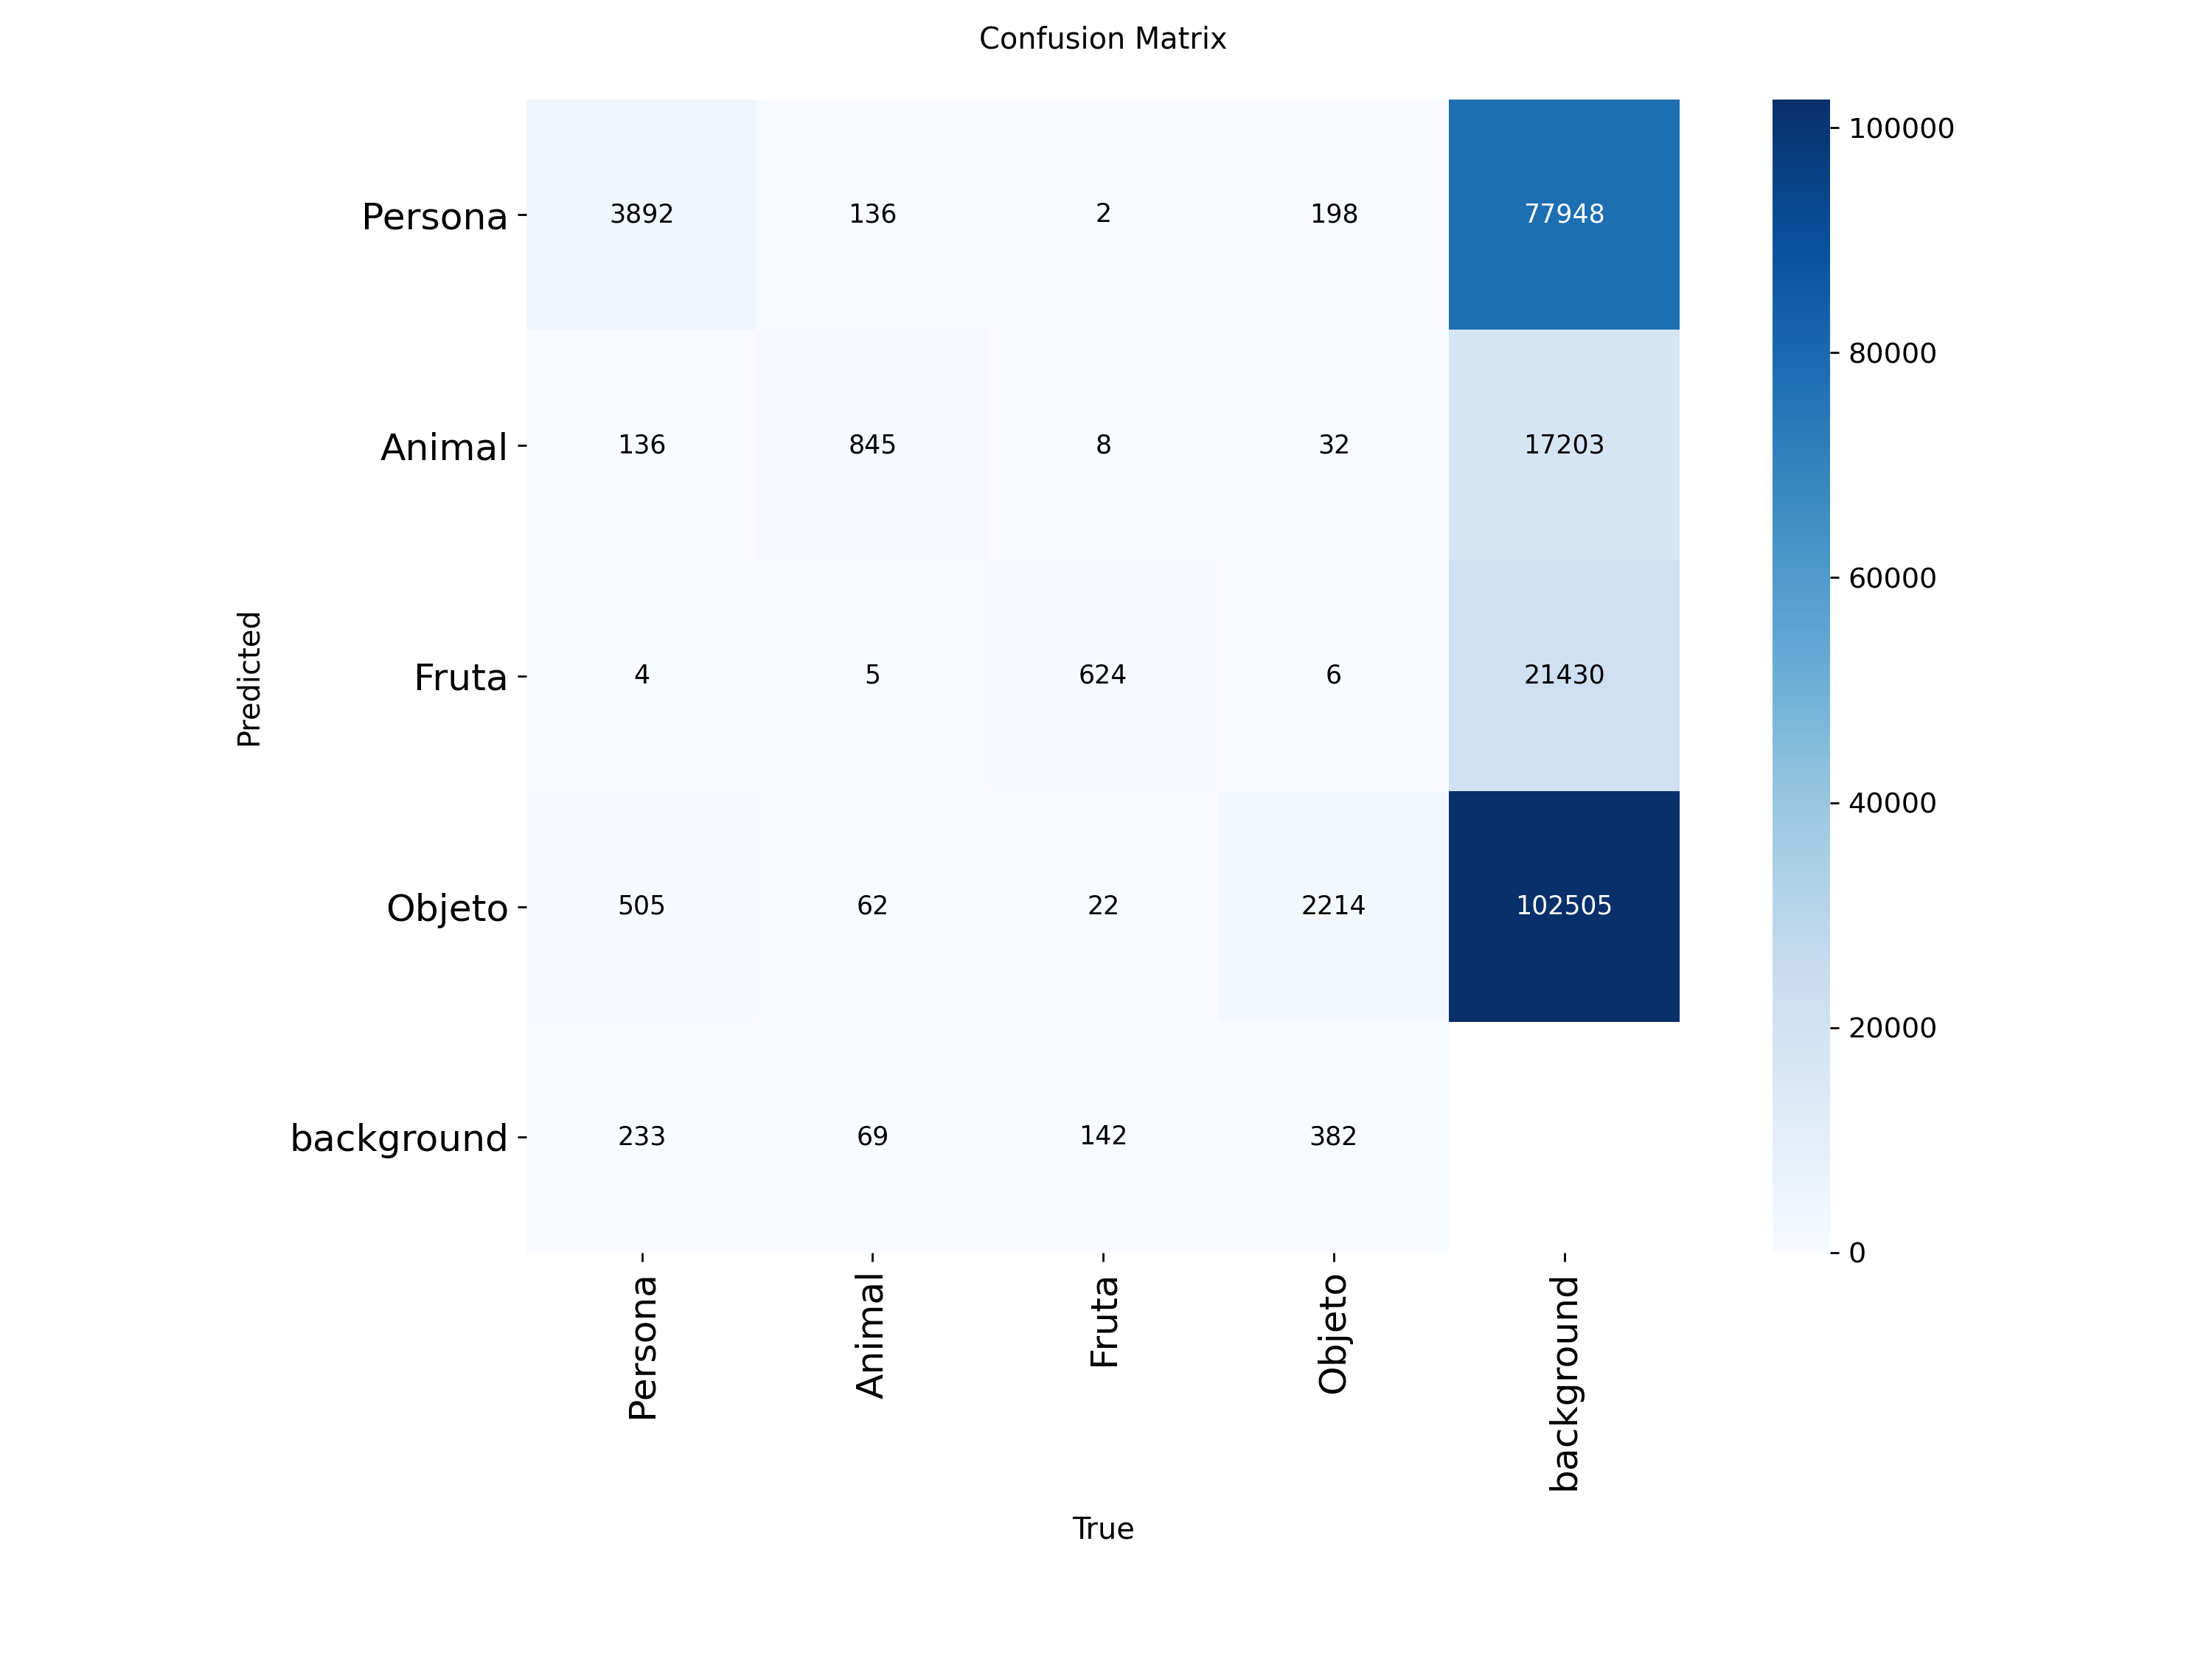

In [ ]:
from IPython.display import Image, display

print("=== MATRIZ DE CONFUSION ===")

display(Image(filename="/content/runs/detect/val/confusion_matrix.png"))

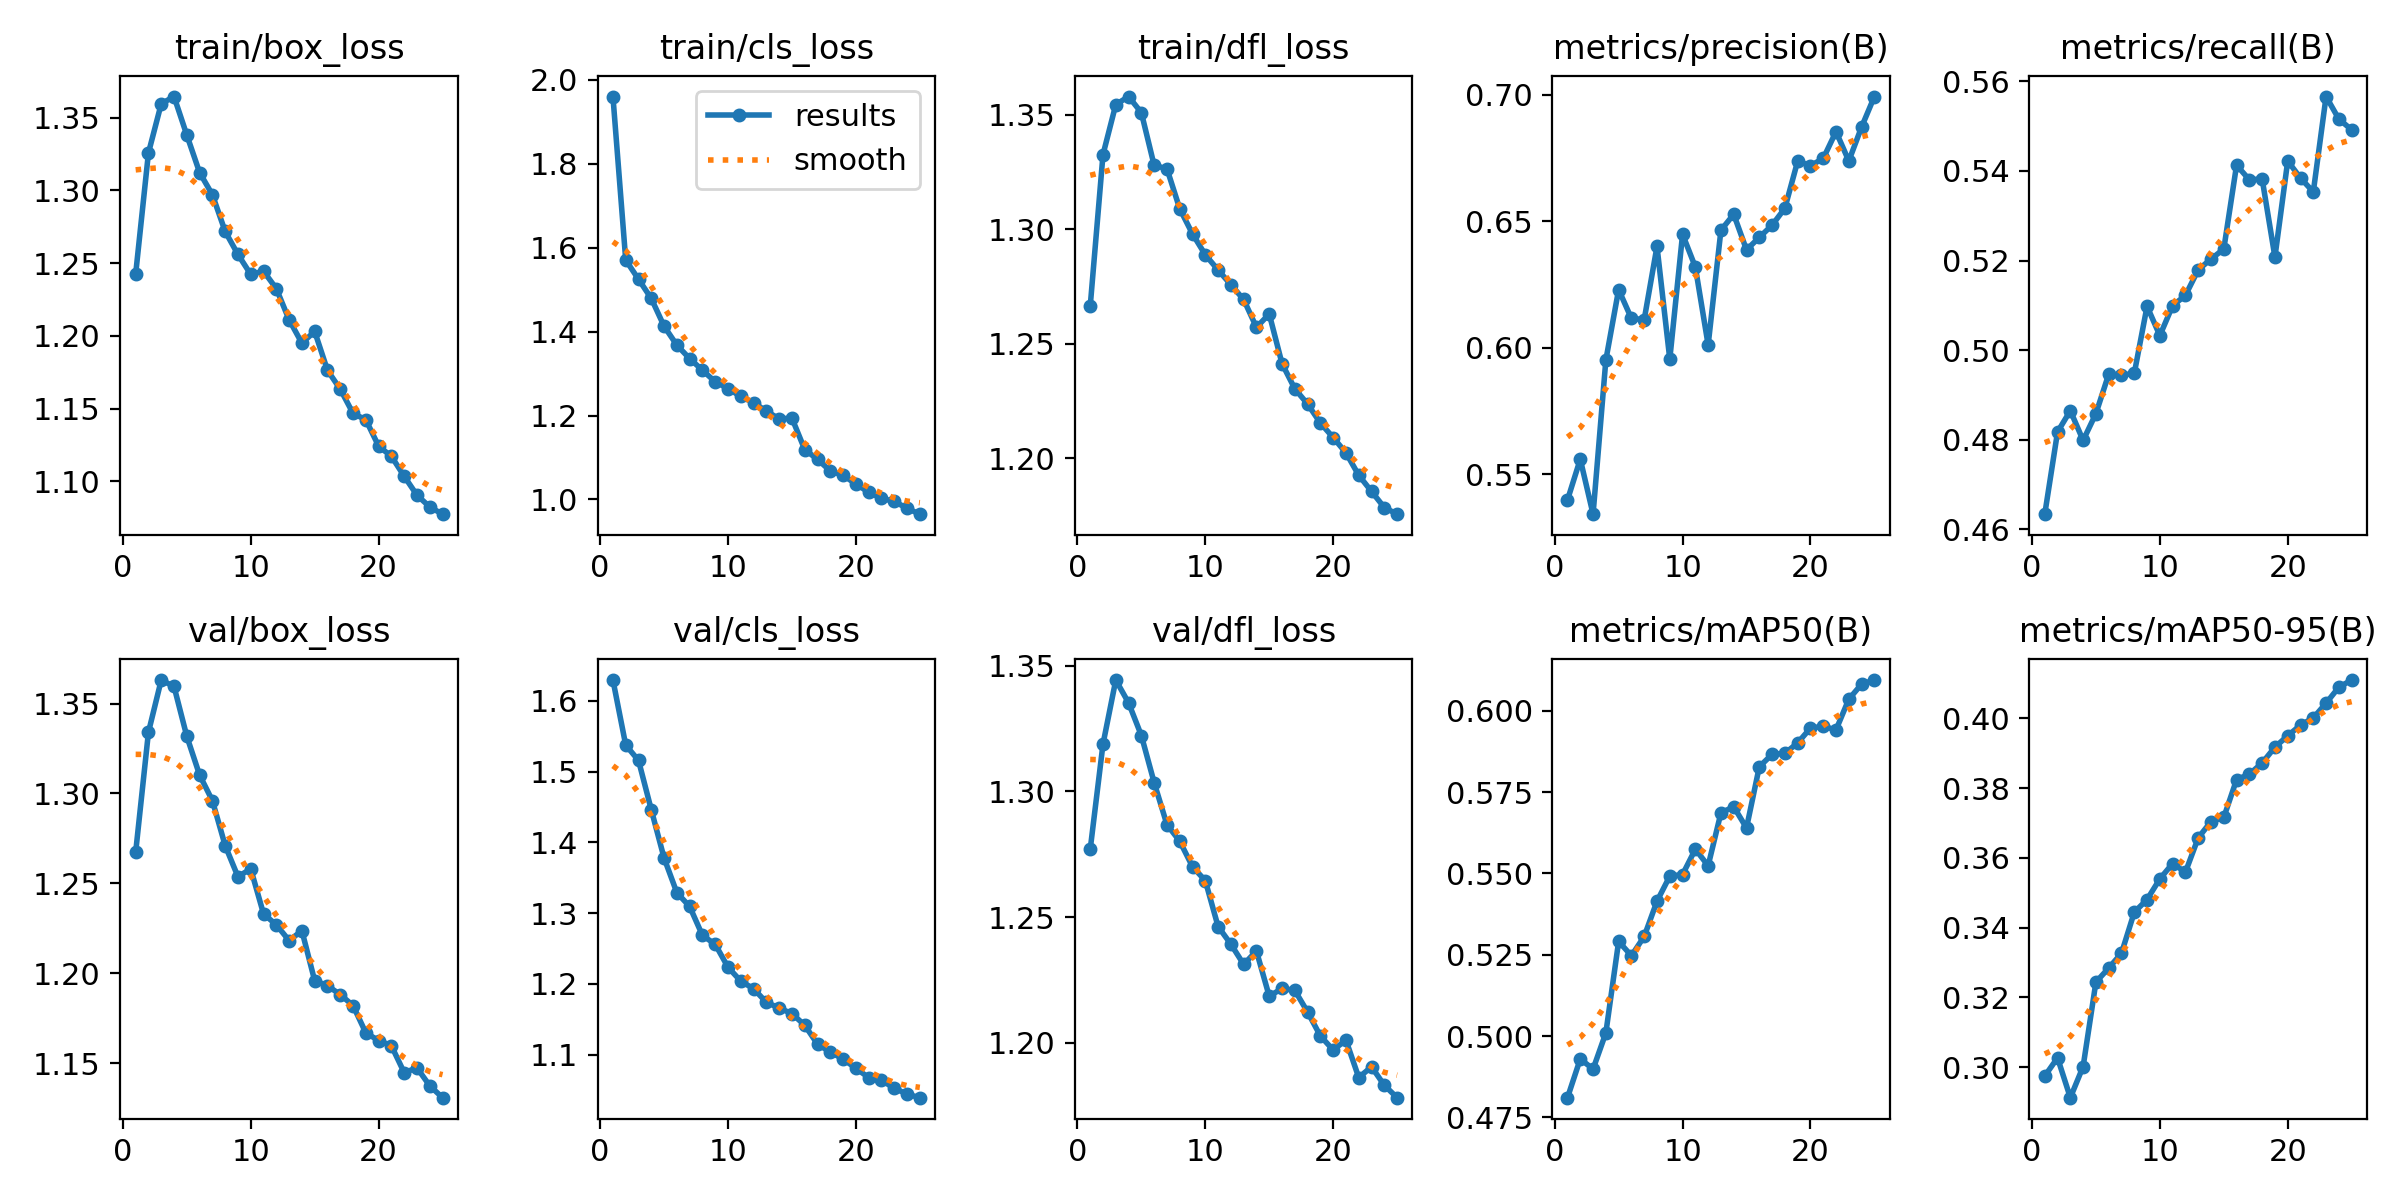

In [ ]:
from IPython.display import Image, display

display(Image("/content/runs/detect/proyecto_u/modelo_4_clases-2/results.png"))

In [ ]:
print("=== RENDIMIENTO DETALLADO POR CATEGORÍA ===")

clases_nombres = ["Persona", "Animal", "Fruta", "Objeto"]

for i, nombre in enumerate(clases_nombres):
    precision_clase = metrics.box.ap50[i] * 100
    print(f"• Clase [{nombre}]: mAP50 = {precision_clase:.2f}%")

=== RENDIMIENTO DETALLADO POR CATEGORÍA ===
• Clase [Persona]: mAP50 = 76.34%
• Clase [Animal]: mAP50 = 78.21%
• Clase [Fruta]: mAP50 = 41.45%
• Clase [Objeto]: mAP50 = 50.22%


In [ ]:
modelo_guardado_path = "/content/best_yolov8n_custom.pt"
best_model.save(modelo_guardado_path)

print(f"Modelo guardado exitosamente en: {modelo_guardado_path}")

Modelo guardado exitosamente en: /content/best_yolov8n_custom.pt


#Probando con la imagen reconstruida


image 1/1 /content/reconstruida_bordes.png: 640x640 2 Animals, 7.4ms
Speed: 3.1ms preprocess, 7.4ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/proyecto_u/prueba_reconstruida-2
=== RESULTADO DE LA PREDICCIÓN ===


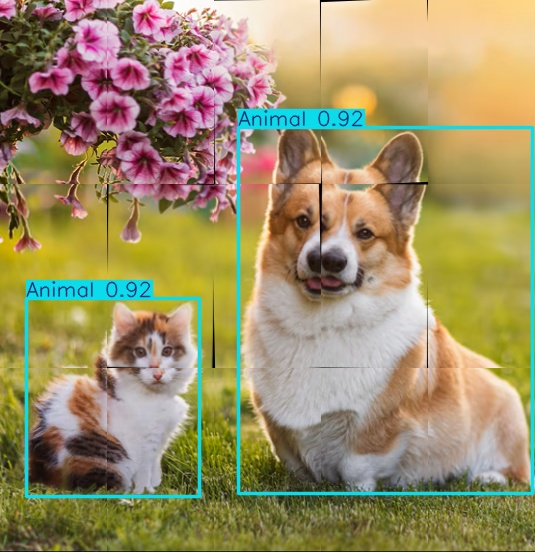

In [ ]:
from IPython.display import Image, display

# Predicción con el modelo entrenado
resultados_prediccion = best_model.predict(
    source="/content/reconstruida_bordes.png",
    save=True,
    imgsz=640,
    conf=0.25,
    project="/content/proyecto_u",
    name="prueba_reconstruida"
)

print("=== RESULTADO DE LA PREDICCIÓN ===")

display(
    Image(filename="/content/proyecto_u/prueba_reconstruida/reconstruida_bordes.jpg")
)